In [315]:
#from google.colab import drive
#drive.mount('/content/drive')
#import os
#os.chdir('/content/drive/MyDrive/ML group project')

In [316]:
#!pip install sktime

In [317]:
import pandas as pd
import numpy as np
from sktime.forecasting.compose import EnsembleForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.forecasting.compose import make_reduction
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import time
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

In [318]:
random_state = 42

# Preprocessing

## Offshore data

In [321]:
df = pd.read_csv("data/final_offshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})
# Removing data from 2025
df = df[df['full_datetime'] < "2025-01-01-01"]

# Convert 'correct days' to datetype format for further processing
df[['date', 'hour']] = df['correct_days'].str.rsplit('-', n=1, expand=True)

df['hour'] = df['hour'].astype(int) - 1

df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'], unit='h')

df.tail()
# Create a unique numerical index
#data['unique_id'] = range(1, len(data)+1)  # Ensuring uniqueness

df = df.drop(['year_mon_day', 'hour', 'full_datetime', 'capacity', 'emission', 'emissionfactor', 'percentage', 'date', 'correct_days', "wind_speed_h_avg"], axis = 1)

# Set datetime as index
df = df.set_index('datetime')

# Monthly averages
df_m = df.resample('M').mean()

# Weekly averages
df_w = df.resample('W').mean()
# Remove last row for 2025-01-05
df_w = df_w.iloc[:-1]

# Daily averages
df_d = df.resample('D').mean()

In [322]:
df.head()

,wind_dir_avg_10,wind_speed_avg_10,air_pressure,humidity,volume
datetime,,,,,
2017-01-01 00:00:00,213.586816,86.428571,10206.75,95.714286,873501
2017-01-01 01:00:00,210.905296,90.714286,10199.75,96.142857,883749
2017-01-01 02:00:00,208.585001,87.857143,10191.50,96.000000,872500
2017-01-01 03:00:00,209.977979,90.000000,10182.25,96.142857,889750
2017-01-01 04:00:00,208.541568,87.142857,10176.25,95.571429,893251


### Monthly data preprocessing

In [324]:
# Split data into target and exogenous variables
y_m = df_m['volume']
X_m = df_m.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_off_m, y_test_off_m, X_train_off_m, X_test_off_m = temporal_train_test_split(y_m, X_m, test_size=0.0625)


# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_off_m)
X_test_norm = preprocessor.transform(X_test_off_m)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_off_m = pd.DataFrame(X_train_norm, columns=X_train_off_m.columns, index=X_train_off_m.index)
X_test_off_m = pd.DataFrame(X_test_norm, columns=X_test_off_m.columns, index=X_test_off_m.index)

### Weekly data preprocessing

In [326]:
# Split data into target and exogenous variables
y_w = df_w['volume']
X_w = df_w.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_off_w, y_test_off_w, X_train_off_w, X_test_off_w = temporal_train_test_split(y_w, X_w, test_size=0.0287)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_off_w)
X_test_norm = preprocessor.transform(X_test_off_w)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_off_w = pd.DataFrame(X_train_norm, columns=X_train_off_w.columns, index=X_train_off_w.index)
X_test_off_w = pd.DataFrame(X_test_norm, columns=X_test_off_w.columns, index=X_test_off_w.index)

### Daily data preprocessing

In [328]:
# Split data into target and exogenous variables
y_d = df_d['volume']
X_d = df_d.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_off_d, y_test_off_d, X_train_off_d, X_test_off_d = temporal_train_test_split(y_d, X_d, test_size=0.02053)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_off_d)
X_test_norm = preprocessor.transform(X_test_off_d)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_off_d = pd.DataFrame(X_train_norm, columns=X_train_off_d.columns, index=X_train_off_d.index)
X_test_off_d = pd.DataFrame(X_test_norm, columns=X_test_off_d.columns, index=X_test_off_d.index)

### Hourly data preprocessing

In [330]:
# Split data into target and exogenous variables
y_h = df['volume']
X_h = df.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_off_h, y_test_off_h, X_train_off_h, X_test_off_h = temporal_train_test_split(y_h, X_h, test_size=0.00239)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_off_h)
X_test_norm = preprocessor.transform(X_test_off_h)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_off_h = pd.DataFrame(X_train_norm, columns=X_train_off_h.columns, index=X_train_off_h.index)
X_test_off_h = pd.DataFrame(X_test_norm, columns=X_test_off_h.columns, index=X_test_off_h.index)

In [331]:
y_d.shape

(2922,)

## Onshore data

In [333]:
df = pd.read_csv("data/final_onshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})
# Removing data from 2025
df = df[df['full_datetime'] < "2025-01-01-01"]

# Convert 'correct days' to datetype format for further processing
df[['date', 'hour']] = df['correct_days'].str.rsplit('-', n=1, expand=True)

df['hour'] = df['hour'].astype(int) - 1

df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'], unit='h')

df.tail()
# Create a unique numerical index
#data['unique_id'] = range(1, len(data)+1)  # Ensuring uniqueness

df = df.drop(['year_mon_day', 'hour', 'full_datetime', 'capacity', 'emission', 'emissionfactor','percentage', 'date', 'correct_days',  'wind_speed_h_avg'], axis = 1)

# Set datetime as index
df = df.set_index('datetime')

# Monthly averages
df_m = df.resample('M').mean()

# Weekly averages
df_w = df.resample('W').mean()
# Remove last row for 2025-01-05
df_w = df_w.iloc[:-1]

# Daily averages
df_d = df.resample('D').mean()

### Monthly data preprocessing

In [335]:
# Split data into target and exogenous variables
y_m = df_m['volume']
X_m = df_m.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_on_m, y_test_on_m, X_train_on_m, X_test_on_m = temporal_train_test_split(y_m, X_m, test_size=0.0625)


# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_on_m)
X_test_norm = preprocessor.transform(X_test_on_m)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_on_m = pd.DataFrame(X_train_norm, columns=X_train_on_m.columns, index=X_train_on_m.index)
X_test_on_m = pd.DataFrame(X_test_norm, columns=X_test_on_m.columns, index=X_test_on_m.index)

### Weekly data preprocessing

In [337]:
# Split data into target and exogenous variables
y_w = df_w['volume']
X_w = df_w.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_on_w, y_test_on_w, X_train_on_w, X_test_on_w = temporal_train_test_split(y_w, X_w, test_size=0.0287)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_on_w)
X_test_norm = preprocessor.transform(X_test_on_w)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_on_w = pd.DataFrame(X_train_norm, columns=X_train_on_w.columns, index=X_train_on_w.index)
X_test_on_w = pd.DataFrame(X_test_norm, columns=X_test_on_w.columns, index=X_test_on_w.index)

### Daily data preprocessing

In [339]:
# Split data into target and exogenous variables
y_d = df_d['volume']
X_d = df_d.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_on_d, y_test_on_d, X_train_on_d, X_test_on_d = temporal_train_test_split(y_d, X_d, test_size=0.02053)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_on_d)
X_test_norm = preprocessor.transform(X_test_on_d)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_on_d = pd.DataFrame(X_train_norm, columns=X_train_on_d.columns, index=X_train_on_d.index)
X_test_on_d = pd.DataFrame(X_test_norm, columns=X_test_on_d.columns, index=X_test_on_d.index)

### Hourly data preprocessing

In [341]:
# Split data into target and exogenous variables
y_h = df['volume']
X_h = df.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_on_h, y_test_on_h, X_train_on_h, X_test_on_h = temporal_train_test_split(y_h, X_h, test_size=0.00239)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_on_h)
X_test_norm = preprocessor.transform(X_test_on_h)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_on_h = pd.DataFrame(X_train_norm, columns=X_train_on_h.columns, index=X_train_on_h.index)
X_test_on_h = pd.DataFrame(X_test_norm, columns=X_test_on_h.columns, index=X_test_on_h.index)

# Forecast - Ensemble model

## Offshore data

### Monthly forecast

In [345]:
# Forecasting horizon: next 6 months (assuming monthly frequency in y)
fh = ForecastingHorizon(np.arange(1, len(y_test_off_m) + 1), freq = 'M')  # 12 future months

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree=18)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators = 10, min_samples_leaf = 1, random_state = random_state), 
                          window_length=2, strategy="recursive")),
]

# Create ensemble
weights = [0.6, 0.4]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit model
start_time = time.time()
weighted_ensemble.fit(y_train_off_m, X=X_train_off_m, fh=fh)

# Forecast
ens_pred_off_m = weighted_ensemble.predict(fh, X=X_test_off_m)

# Evaluate
mape = mean_absolute_percentage_error(y_test_off_m, ens_pred_off_m)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
print(f"Execution Time: {end_time - start_time:.4f} seconds")

print("RMSE:", mean_squared_error(y_test_off_m, ens_pred_off_m)**0.5)
print("MSE:", mean_squared_error(y_test_off_m, ens_pred_off_m))

MAPE: 0.1751
Execution Time: 0.1543 seconds
RMSE: 349878.6232155739
MSE: 122415050983.22554


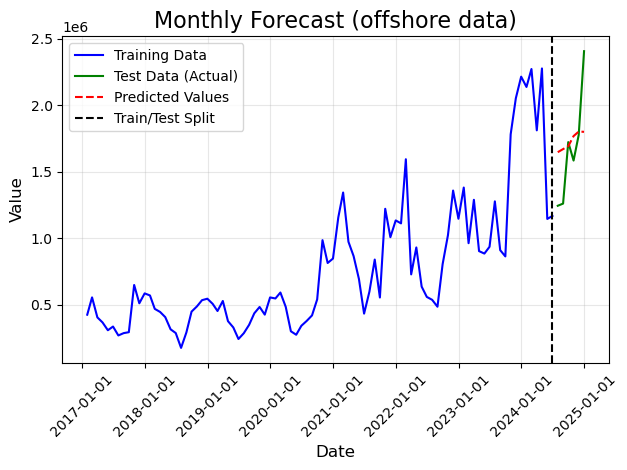

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [346]:
# Plot the data
plt.plot(y_train_off_m.index, y_train_off_m, 'b-', label='Training Data')
plt.plot(y_test_off_m.index, y_test_off_m, 'g-', label='Test Data (Actual)')
plt.plot(ens_pred_off_m.index, ens_pred_off_m, 'r--', label='Predicted Values')

# Add a vertical line at the train/test split
split_date = y_train_off_m.index[-1]
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')

# Customize the plot
plt.title("Monthly Forecast (offshore data)", fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(loc='best', fontsize=10)

# Format x-axis dates
date_format = DateFormatter("%Y-%m-%d")
plt.gca().xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)

# Add grid and tight layout
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparison of multiple models
figsize = (15, 10)
plt.figure(figsize=figsize)


### Weekly forecast

In [348]:
# Forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_off_w) + 1), freq = 'W')  # 24 future weeks

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 50)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=74, min_samples_leaf = 30, random_state = random_state), 
                          window_length=5, strategy="recursive")),
]

# Create ensemble
weights = [0.4, 0.6]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit model
start_time = time.time()
weighted_ensemble.fit(y_train_off_w, X = X_train_off_w)

# Forecast
ens_pred_off_w = weighted_ensemble.predict(fh, X = X_test_off_w)

# Evaluate
mape = mean_absolute_percentage_error(y_test_off_w, ens_pred_off_w)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
print(f"Execution Time: {end_time - start_time:.4f} seconds")

print("RMSE:", mean_squared_error(y_test_off_w, ens_pred_off_w)**0.5)
print("MSE:", mean_squared_error(y_test_off_w, ens_pred_off_w))

MAPE: 0.6388
Execution Time: 0.7367 seconds
RMSE: 853630.7108154359
MSE: 728685390447.2664


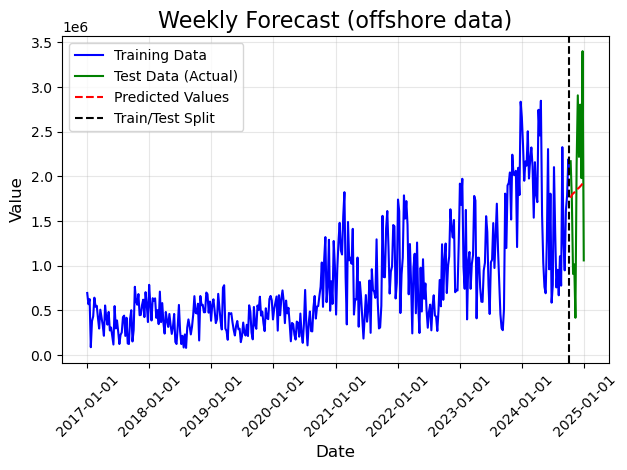

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [349]:
# Plot the data
plt.plot(y_train_off_w.index, y_train_off_w, 'b-', label='Training Data')
plt.plot(y_test_off_w.index, y_test_off_w, 'g-', label='Test Data (Actual)')
plt.plot(ens_pred_off_w.index, ens_pred_off_w, 'r--', label='Predicted Values')

# Add a vertical line at the train/test split
split_date = y_train_off_w.index[-1]
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')

# Customize the plot
plt.title("Weekly Forecast (offshore data)", fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(loc='best', fontsize=10)

# Format x-axis dates
date_format = DateFormatter("%Y-%m-%d")
plt.gca().xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)

# Add grid and tight layout
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparison of multiple models
figsize = (15, 10)
plt.figure(figsize=figsize)


### Daily forecast

In [351]:
# Forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_off_d) + 1), freq = 'D')  # 84 future days

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 55)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=10, min_samples_leaf = 18, random_state = random_state), 
                          window_length = 5, strategy="recursive")),
]

# Create ensemble
weights = [0.95, 0.05]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit model
start_time = time.time()
weighted_ensemble.fit(y_train_off_d, X = X_train_off_d)

# Forecast
ens_pred_off_d = weighted_ensemble.predict(fh, X = X_test_off_d)

# Evaluate
mape = mean_absolute_percentage_error(y_test_off_d, ens_pred_off_d)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
print(f"Execution Time: {end_time - start_time:.4f} seconds")

print("RMSE:", mean_squared_error(y_test_off_d, ens_pred_off_d)**0.5)
print("MSE:", mean_squared_error(y_test_off_d, ens_pred_off_d))

MAPE: 4.3973
Execution Time: 1.4496 seconds
RMSE: 1294037.7646578415
MSE: 1674533736360.663


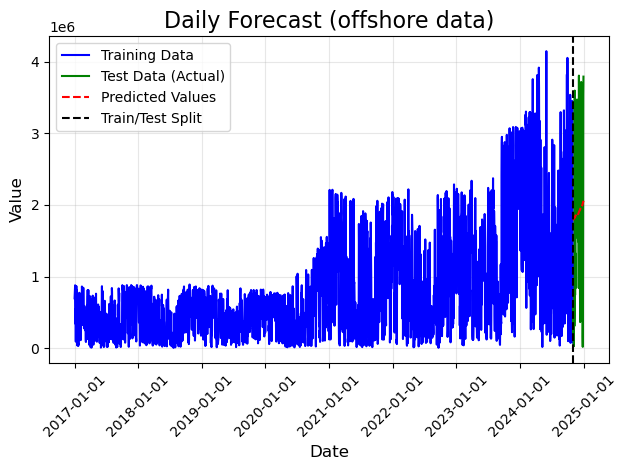

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [352]:
# Plot the data
plt.plot(y_train_off_d.index, y_train_off_d, 'b-', label='Training Data')
plt.plot(y_test_off_d.index, y_test_off_d, 'g-', label='Test Data (Actual)')
plt.plot(ens_pred_off_d.index, ens_pred_off_d, 'r--', label='Predicted Values')

# Add a vertical line at the train/test split
split_date = y_train_off_d.index[-1]
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')

# Customize the plot
plt.title("Daily Forecast (offshore data)", fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(loc='best', fontsize=10)

# Format x-axis dates
date_format = DateFormatter("%Y-%m-%d")
plt.gca().xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)

# Add grid and tight layout
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparison of multiple models
figsize = (15, 10)
plt.figure(figsize=figsize)


### Hourly forecast

In [354]:
# Define forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_off_h) + 1), freq = 'H')

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 56)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=100, min_samples_leaf = 10, random_state = random_state), 
                          window_length = 5, strategy="recursive")),
]

# With custom weights (must sum to 1)
weights = [0.5, 0.5]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

start_time = time.time()

# Fit the ensemble with exogenous variables
weighted_ensemble.fit(y_train_off_h, X=X_train_off_h)

# Generate forecasts
ens_pred_off_h = weighted_ensemble.predict(fh, X=X_test_off_h)

# Evaluate
mape = mean_absolute_percentage_error(y_test_off_h, ens_pred_off_h)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
execution_time = end_time - start_time
print(f"Execution Time: {execution_time:.4f} seconds")
print("RMSE:", mean_squared_error(y_test_off_h, ens_pred_off_h)**0.5)
print("MSE:", mean_squared_error(y_test_off_h, ens_pred_off_h))

MAPE: 125769334629752471552.0000
Execution Time: 417.4783 seconds
RMSE: 1537748.0410328875
MSE: 2364669037700.4834


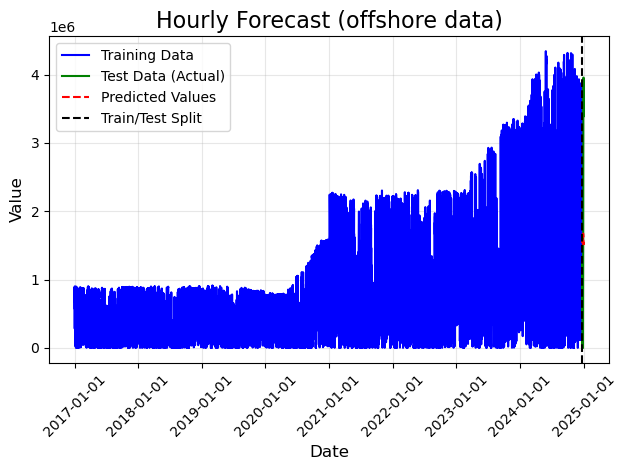

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [355]:
# Plot the data
plt.plot(y_train_off_h.index, y_train_off_h, 'b-', label='Training Data')
plt.plot(y_test_off_h.index, y_test_off_h, 'g-', label='Test Data (Actual)')
plt.plot(ens_pred_off_h.index, ens_pred_off_h, 'r--', label='Predicted Values')

# Add a vertical line at the train/test split
split_date = y_train_off_h.index[-1]
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')

# Customize the plot
plt.title("Hourly Forecast (offshore data)", fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(loc='best', fontsize=10)

# Format x-axis dates
date_format = DateFormatter("%Y-%m-%d")
plt.gca().xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)

# Add grid and tight layout
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparison of multiple models
figsize = (15, 10)
plt.figure(figsize=figsize)


## Onshore data

### Monthly forecast

In [358]:
# Forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_on_m) + 1), freq = 'M')  # 12 future months

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 5)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators = 4, min_samples_leaf = 1, random_state = random_state), 
                          window_length=2, strategy="recursive")),
]

# Create ensemble with equal weights
weights = [0.2, 0.8]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit model
start_time = time.time()
weighted_ensemble.fit(y_train_on_m, X=X_train_on_m, fh=fh)

# Forecast
ens_pred_on_m = weighted_ensemble.predict(fh, X=X_test_on_m)

# Evaluate
mape = mean_absolute_percentage_error(y_test_on_m, ens_pred_on_m)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
print(f"Execution Time: {end_time - start_time:.4f} seconds")

print("RMSE:", mean_squared_error(y_test_on_m, ens_pred_on_m)**0.5)
print("MSE:", mean_squared_error(y_test_on_m, ens_pred_on_m))

MAPE: 0.1151
Execution Time: 0.1567 seconds
RMSE: 414908.78963394475
MSE: 172149303715.50504


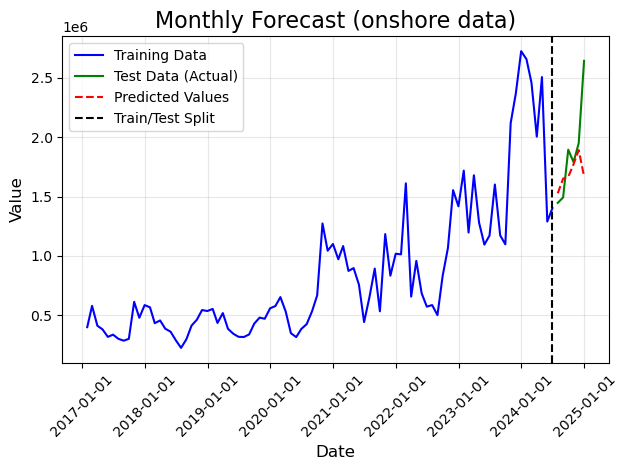

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [359]:
# Plot the data
plt.plot(y_train_on_m.index, y_train_on_m, 'b-', label='Training Data')
plt.plot(y_test_on_m.index, y_test_on_m, 'g-', label='Test Data (Actual)')
plt.plot(ens_pred_on_m.index, ens_pred_on_m, 'r--', label='Predicted Values')

# Add a vertical line at the train/test split
split_date = y_train_on_m.index[-1]
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')

# Customize the plot
plt.title("Monthly Forecast (onshore data)", fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(loc='best', fontsize=10)

# Format x-axis dates
date_format = DateFormatter("%Y-%m-%d")
plt.gca().xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)

# Add grid and tight layout
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparison of multiple models
figsize = (15, 10)
plt.figure(figsize=figsize)


### Weekly forecast

In [361]:
# Forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_on_w) + 1), freq = 'W')  # 24 future weeks

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 1)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=26, min_samples_leaf = 29, random_state = random_state), 
                          window_length=5, strategy="recursive")),
]

# Create ensemble
weights = [0, 1]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit model
start_time = time.time()
weighted_ensemble.fit(y_train_on_w, X = X_train_on_w)

# Forecast
ens_pred_on_w = weighted_ensemble.predict(fh, X = X_test_on_w)

# Evaluate
mape = mean_absolute_percentage_error(y_test_on_w, ens_pred_on_w)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
print(f"Execution Time: {end_time - start_time:.4f} seconds")

print("RMSE:", mean_squared_error(y_test_on_w, ens_pred_on_w)**0.5)
print("MSE:", mean_squared_error(y_test_on_w, ens_pred_on_w))

MAPE: 0.6486
Execution Time: 0.3794 seconds
RMSE: 971486.9849350753
MSE: 943786961898.2433


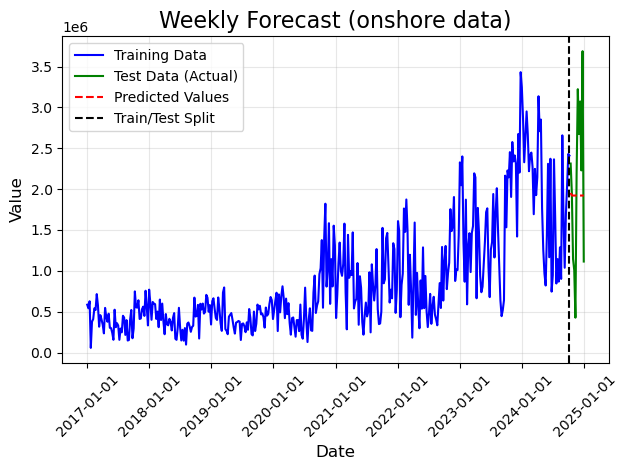

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [362]:
# Plot the data
plt.plot(y_train_on_w.index, y_train_on_w, 'b-', label='Training Data')
plt.plot(y_test_on_w.index, y_test_on_w, 'g-', label='Test Data (Actual)')
plt.plot(ens_pred_on_w.index, ens_pred_on_w, 'r--', label='Predicted Values')

# Add a vertical line at the train/test split
split_date = y_train_on_w.index[-1]
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')

# Customize the plot
plt.title("Weekly Forecast (onshore data)", fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(loc='best', fontsize=10)

# Format x-axis dates
date_format = DateFormatter("%Y-%m-%d")
plt.gca().xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)

# Add grid and tight layout
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparison of multiple models
figsize = (15, 10)
plt.figure(figsize=figsize)


### Daily forecast

In [364]:
# Forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_on_d) + 1), freq = 'D')  # 84 future days

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 71)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=100, min_samples_leaf = 16, random_state = random_state), 
                          window_length = 5, strategy="recursive")),
]

# Create ensemble
weights = [1, 0]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit model
start_time = time.time()
weighted_ensemble.fit(y_train_on_d, X = X_train_on_d)

# Forecast
ens_pred_on_d = weighted_ensemble.predict(fh, X = X_test_on_d)

# Evaluate
mape = mean_absolute_percentage_error(y_test_on_d, ens_pred_on_d)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
print(f"Execution Time: {end_time - start_time:.4f} seconds")

print("RMSE:", mean_squared_error(y_test_on_d, ens_pred_on_d)**0.5)
print("MSE:", mean_squared_error(y_test_on_d, ens_pred_on_d))

MAPE: 3.8757
Execution Time: 13.8228 seconds
RMSE: 1461656.880000765
MSE: 2136440834853.5703


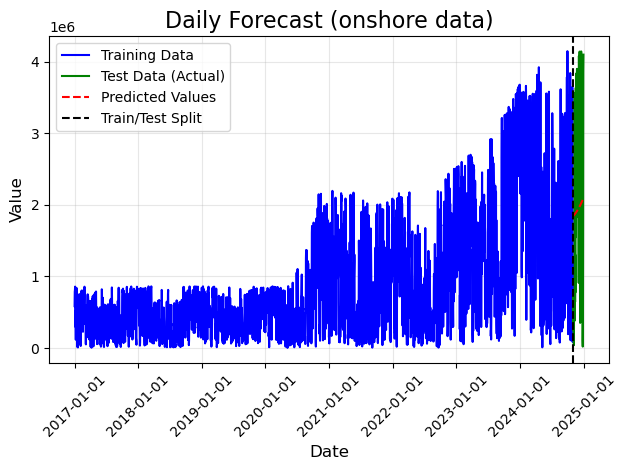

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [365]:
# Plot the data
plt.plot(y_train_on_d.index, y_train_on_d, 'b-', label='Training Data')
plt.plot(y_test_on_d.index, y_test_on_d, 'g-', label='Test Data (Actual)')
plt.plot(ens_pred_on_d.index, ens_pred_on_d, 'r--', label='Predicted Values')

# Add a vertical line at the train/test split
split_date = y_train_on_d.index[-1]
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')

# Customize the plot
plt.title("Daily Forecast (onshore data)", fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(loc='best', fontsize=10)

# Format x-axis dates
date_format = DateFormatter("%Y-%m-%d")
plt.gca().xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)

# Add grid and tight layout
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparison of multiple models
figsize = (15, 10)
plt.figure(figsize=figsize)


### Hourly forecast

In [367]:
# Define forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_on_h) + 1), freq = 'H')

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 56)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=50, min_samples_leaf = 30, random_state = random_state), 
                          window_length = 5, strategy="recursive")),
]

# With custom weights (must sum to 1)
weights = [0.3, 0.7]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

start_time = time.time()

# Fit the ensemble with exogenous variables
weighted_ensemble.fit(y_train_on_h, X=X_train_on_h)

# Generate forecasts
ens_pred_on_h = weighted_ensemble.predict(fh, X=X_test_on_h)

# Evaluate
mape = mean_absolute_percentage_error(y_test_on_h, ens_pred_on_h)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
execution_time = end_time - start_time
print(f"Execution Time: {execution_time:.4f} seconds")
print("RMSE:", mean_squared_error(y_test_on_h, ens_pred_on_h)**0.5)
print("MSE:", mean_squared_error(y_test_on_h, ens_pred_on_h))

MAPE: 470837245456448618496.0000
Execution Time: 202.6622 seconds
RMSE: 1625782.428084151
MSE: 2643168503467.1973


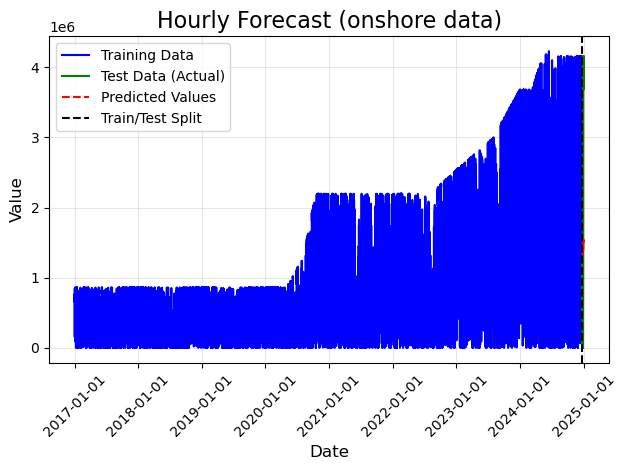

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [368]:
# Plot the data
plt.plot(y_train_on_h.index, y_train_on_h, 'b-', label='Training Data')
plt.plot(y_test_on_h.index, y_test_on_h, 'g-', label='Test Data (Actual)')
plt.plot(ens_pred_on_h.index, ens_pred_on_h, 'r--', label='Predicted Values')

# Add a vertical line at the train/test split
split_date = y_train_on_h.index[-1]
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')

# Customize the plot
plt.title("Hourly Forecast (onshore data)", fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(loc='best', fontsize=10)

# Format x-axis dates
date_format = DateFormatter("%Y-%m-%d")
plt.gca().xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)

# Add grid and tight layout
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparison of multiple models
figsize = (15, 10)
plt.figure(figsize=figsize)
